In [1]:
!pip install gymnasium
!pip install tensorflow
!pip install numpy

In [4]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers

# Environment
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = int(env.action_space.n) # Ensure action_size is a standard python int
model = models.Sequential([
    layers.Dense(24, activation='relu', input_shape=(state_size,)),
    layers.Dense(24, activation='relu'),
    layers.Dense(action_size, activation='linear')
])

model.compile(optimizer='adam', loss='mse')

gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 200

for episode in range(episodes):

    state, _ = env.reset()
    state = np.reshape(state, [1, state_size])

    done = False
    total_reward = 0

    while not done:

      # Exploration vs exploitation
      if np.random.rand() < epsilon:
        action = env.action_space.sample()
      else:
        q_values = model.predict(state, verbose=0)
        action = np.argmax(q_values[0])

      next_state, reward, terminated, truncated, _ = env.step(action)
      done = terminated or truncated

      next_state = np.reshape(next_state, [1, state_size])
      target = reward

      if not done:
        target += gamma * np.max(model.predict(next_state, verbose=0)[0])

      target_f = model.predict(state, verbose=0)
      target_f[0][action] = target

      model.fit(state, target_f, epochs=1, verbose=0)

      state = next_state
      total_reward += reward

    if epsilon > epsilon_min:
      epsilon *= epsilon_decay

    print("Episode:", episode, "Score:", total_reward)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Episode: 0 Score: 12.0
Episode: 1 Score: 19.0
Episode: 2 Score: 36.0
Episode: 3 Score: 21.0
Episode: 4 Score: 19.0
Episode: 5 Score: 20.0
Episode: 6 Score: 24.0
Episode: 7 Score: 14.0
Episode: 8 Score: 15.0
Episode: 9 Score: 12.0
Episode: 10 Score: 12.0
Episode: 11 Score: 18.0
Episode: 12 Score: 12.0
Episode: 13 Score: 17.0
Episode: 14 Score: 14.0
Episode: 15 Score: 12.0
Episode: 16 Score: 25.0
Episode: 17 Score: 13.0
Episode: 18 Score: 42.0
Episode: 19 Score: 24.0
Episode: 20 Score: 11.0
Episode: 21 Score: 88.0
Episode: 22 Score: 21.0
Episode: 23 Score: 31.0
Episode: 24 Score: 13.0
Episode: 25 Score: 12.0
Episode: 26 Score: 11.0
Episode: 27 Score: 13.0
Episode: 28 Score: 37.0
Episode: 29 Score: 20.0
Episode: 30 Score: 36.0
Episode: 31 Score: 10.0
Episode: 32 Score: 14.0
Episode: 33 Score: 23.0
Episode: 34 Score: 13.0
Episode: 35 Score: 11.0
Episode: 36 Score: 17.0
Episode: 37 Score: 14.0
Episode: 38 Score: 32.0
Episode: 39 Score: 21.0
Episode: 40 Score: 10.0
Episode: 41 Score: 22.0
Ep

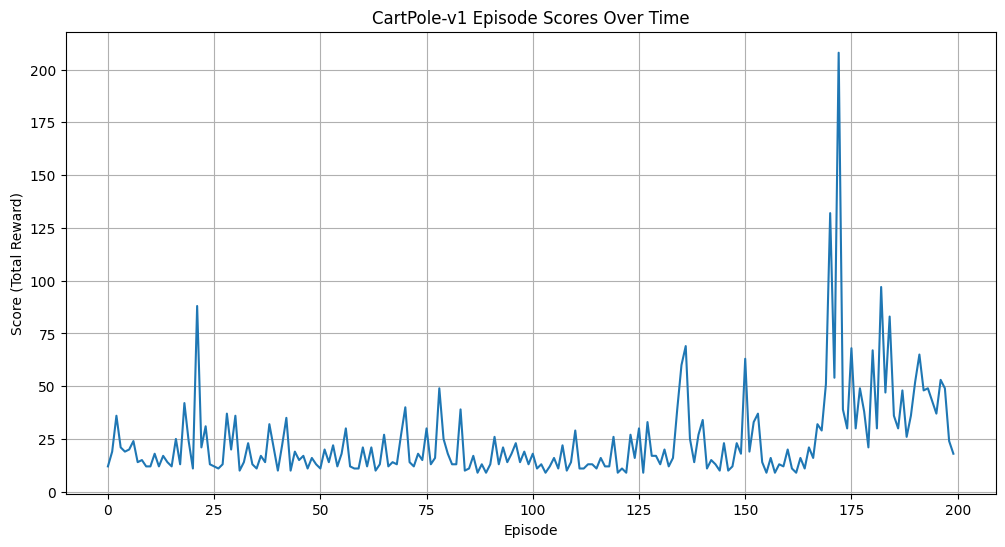

In [5]:
import matplotlib.pyplot as plt
scores = []
output_lines = '''Episode: 0 Score: 12.0
Episode: 1 Score: 19.0
Episode: 2 Score: 36.0
Episode: 3 Score: 21.0
Episode: 4 Score: 19.0
Episode: 5 Score: 20.0
Episode: 6 Score: 24.0
Episode: 7 Score: 14.0
Episode: 8 Score: 15.0
Episode: 9 Score: 12.0
Episode: 10 Score: 12.0
Episode: 11 Score: 18.0
Episode: 12 Score: 12.0
Episode: 13 Score: 17.0
Episode: 14 Score: 14.0
Episode: 15 Score: 12.0
Episode: 16 Score: 25.0
Episode: 17 Score: 13.0
Episode: 18 Score: 42.0
Episode: 19 Score: 24.0
Episode: 20 Score: 11.0
Episode: 21 Score: 88.0
Episode: 22 Score: 21.0
Episode: 23 Score: 31.0
Episode: 24 Score: 13.0
Episode: 25 Score: 12.0
Episode: 26 Score: 11.0
Episode: 27 Score: 13.0
Episode: 28 Score: 37.0
Episode: 29 Score: 20.0
Episode: 30 Score: 36.0
Episode: 31 Score: 10.0
Episode: 32 Score: 14.0
Episode: 33 Score: 23.0
Episode: 34 Score: 13.0
Episode: 35 Score: 11.0
Episode: 36 Score: 17.0
Episode: 37 Score: 14.0
Episode: 38 Score: 32.0
Episode: 39 Score: 21.0
Episode: 40 Score: 10.0
Episode: 41 Score: 22.0
Episode: 42 Score: 35.0
Episode: 43 Score: 10.0
Episode: 44 Score: 19.0
Episode: 45 Score: 15.0
Episode: 46 Score: 17.0
Episode: 47 Score: 11.0
Episode: 48 Score: 16.0
Episode: 49 Score: 13.0
Episode: 50 Score: 11.0
Episode: 51 Score: 20.0
Episode: 52 Score: 14.0
Episode: 53 Score: 22.0
Episode: 54 Score: 12.0
Episode: 55 Score: 18.0
Episode: 56 Score: 30.0
Episode: 57 Score: 12.0
Episode: 58 Score: 11.0
Episode: 59 Score: 11.0
Episode: 60 Score: 21.0
Episode: 61 Score: 12.0
Episode: 62 Score: 21.0
Episode: 63 Score: 10.0
Episode: 64 Score: 13.0
Episode: 65 Score: 27.0
Episode: 66 Score: 12.0
Episode: 67 Score: 14.0
Episode: 68 Score: 13.0
Episode: 69 Score: 27.0
Episode: 70 Score: 40.0
Episode: 71 Score: 14.0
Episode: 72 Score: 12.0
Episode: 73 Score: 18.0
Episode: 74 Score: 15.0
Episode: 75 Score: 30.0
Episode: 76 Score: 13.0
Episode: 77 Score: 16.0
Episode: 78 Score: 49.0
Episode: 79 Score: 25.0
Episode: 80 Score: 18.0
Episode: 81 Score: 13.0
Episode: 82 Score: 13.0
Episode: 83 Score: 39.0
Episode: 84 Score: 10.0
Episode: 85 Score: 11.0
Episode: 86 Score: 17.0
Episode: 87 Score: 9.0
Episode: 88 Score: 13.0
Episode: 89 Score: 9.0
Episode: 90 Score: 13.0
Episode: 91 Score: 26.0
Episode: 92 Score: 13.0
Episode: 93 Score: 21.0
Episode: 94 Score: 14.0
Episode: 95 Score: 18.0
Episode: 96 Score: 23.0
Episode: 97 Score: 14.0
Episode: 98 Score: 19.0
Episode: 99 Score: 13.0
Episode: 100 Score: 18.0
Episode: 101 Score: 11.0
Episode: 102 Score: 13.0
Episode: 103 Score: 9.0
Episode: 104 Score: 12.0
Episode: 105 Score: 16.0
Episode: 106 Score: 11.0
Episode: 107 Score: 22.0
Episode: 108 Score: 10.0
Episode: 109 Score: 14.0
Episode: 110 Score: 29.0
Episode: 111 Score: 11.0
Episode: 112 Score: 11.0
Episode: 113 Score: 13.0
Episode: 114 Score: 13.0
Episode: 115 Score: 11.0
Episode: 116 Score: 16.0
Episode: 117 Score: 12.0
Episode: 118 Score: 12.0
Episode: 119 Score: 26.0
Episode: 120 Score: 9.0
Episode: 121 Score: 11.0
Episode: 122 Score: 9.0
Episode: 123 Score: 27.0
Episode: 124 Score: 16.0
Episode: 125 Score: 30.0
Episode: 126 Score: 9.0
Episode: 127 Score: 33.0
Episode: 128 Score: 17.0
Episode: 129 Score: 17.0
Episode: 130 Score: 13.0
Episode: 131 Score: 20.0
Episode: 132 Score: 12.0
Episode: 133 Score: 16.0
Episode: 134 Score: 39.0
Episode: 135 Score: 60.0
Episode: 136 Score: 69.0
Episode: 137 Score: 25.0
Episode: 138 Score: 14.0
Episode: 139 Score: 27.0
Episode: 140 Score: 34.0
Episode: 141 Score: 11.0
Episode: 142 Score: 15.0
Episode: 143 Score: 13.0
Episode: 144 Score: 10.0
Episode: 145 Score: 23.0
Episode: 146 Score: 10.0
Episode: 147 Score: 12.0
Episode: 148 Score: 23.0
Episode: 149 Score: 18.0
Episode: 150 Score: 63.0
Episode: 151 Score: 19.0
Episode: 152 Score: 33.0
Episode: 153 Score: 37.0
Episode: 154 Score: 14.0
Episode: 155 Score: 9.0
Episode: 156 Score: 16.0
Episode: 157 Score: 9.0
Episode: 158 Score: 13.0
Episode: 159 Score: 12.0
Episode: 160 Score: 20.0
Episode: 161 Score: 11.0
Episode: 162 Score: 9.0
Episode: 163 Score: 16.0
Episode: 164 Score: 11.0
Episode: 165 Score: 21.0
Episode: 166 Score: 16.0
Episode: 167 Score: 32.0
Episode: 168 Score: 29.0
Episode: 169 Score: 51.0
Episode: 170 Score: 132.0
Episode: 171 Score: 54.0
Episode: 172 Score: 208.0
Episode: 173 Score: 39.0
Episode: 174 Score: 30.0
Episode: 175 Score: 68.0
Episode: 176 Score: 30.0
Episode: 177 Score: 49.0
Episode: 178 Score: 38.0
Episode: 179 Score: 21.0
Episode: 180 Score: 67.0
Episode: 181 Score: 30.0
Episode: 182 Score: 97.0
Episode: 183 Score: 47.0
Episode: 184 Score: 83.0
Episode: 185 Score: 36.0
Episode: 186 Score: 30.0
Episode: 187 Score: 48.0
Episode: 188 Score: 26.0
Episode: 189 Score: 36.0
Episode: 190 Score: 52.0
Episode: 191 Score: 65.0
Episode: 192 Score: 48.0
Episode: 193 Score: 49.0
Episode: 194 Score: 43.0
Episode: 195 Score: 37.0
Episode: 196 Score: 53.0
Episode: 197 Score: 49.0
Episode: 198 Score: 24.0
Episode: 199 Score: 18.0'''

for line in output_lines.splitlines():
    if "Episode:" in line and "Score:" in line:
        try:
            score = float(line.split("Score:")[1].strip())
            scores.append(score)
        except ValueError:
            continue

plt.figure(figsize=(12, 6))
plt.plot(scores)
plt.title('CartPole-v1 Episode Scores Over Time')
plt.xlabel('Episode')
plt.ylabel('Score (Total Reward)')
plt.grid(True)
plt.show()